In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
# Create an array of ones with length 2 and uint8 data type
a=np.ones([2],dtype="uint8")
# Multiply each element by 100
b=a*100
print(b)

[100 100]


In [ ]:
# Values reach their maximum limit (255)
print(b+155)
# Overflow occurs: 100 + 160 = 260 -> (260 % 256) = 4
print(b+160)

[255 255]
[4 4]


In [ ]:
# Create a 2x2 matrix with specific values
m1=np.array([[150,155],[156,157]],dtype="uint8")
# Create a 2x2 matrix of ones multiplied by 100
m2=np.ones([2,2])*100
# Print matrices and their sum (demonstrating overflow where sum > 255)
print(f"m1:{m1} \n\n m2:{m2} \n\n m1+m2= {m1+m2}")

m1:[[150 155]
 [156 157]] 

 m2:[[100. 100.]
 [100. 100.]] 

 m1+m2= [[250. 255.]
 [256. 257.]]


In [5]:
#256 --> more than 255
#257 --> more than 255

solotion for overflow

In [6]:
#convert uint8 to int16 
#فعلا فضای بیشتری برای دیتا ها درست میکنیم 
modified_m1=m1.astype("int16")+m2
print(modified_m1)

[[250. 255.]
 [256. 257.]]


In [7]:
modified_m1=np.minimum(modified_m1,255)
#convert int16 to uint8 agian
modified_m1=modified_m1.astype("uint8")
modified_m1

array([[250, 255],
       [255, 255]], dtype=uint8)

second solotion for overflow

In [8]:
m1=np.array([[150,155],[156,157]],dtype="uint8")

#add 100 to every data
value_to_add=100

#numbers that can be added to 100
max_threshold=255-100

#اگر عدد ماتریس بزرگ تر از 150 بود به جای ان عدد 255 بزار
m1[m1>max_threshold]=255

#اگر عدد کوچکتر از 150 بود با 100 جمعش کن 
m1[m1<max_threshold]+=100

print(m1)

[[250 155]
 [255 255]]


solution openCv for overflow

In [9]:
#modifying pixel values to change image color

image=cv2.imread("girl.png")
m=np.ones(image.shape,dtype="uint8")*100

#با متد cv2.add ماتریس m رو به همه خونه های عکس اضافه میکنیم 
added=cv2.add(image,m)
#با متد subtract ماتریس m  رو از همه خونه ها کم میکنیم
sabtracted=cv2.subtract(image,m)

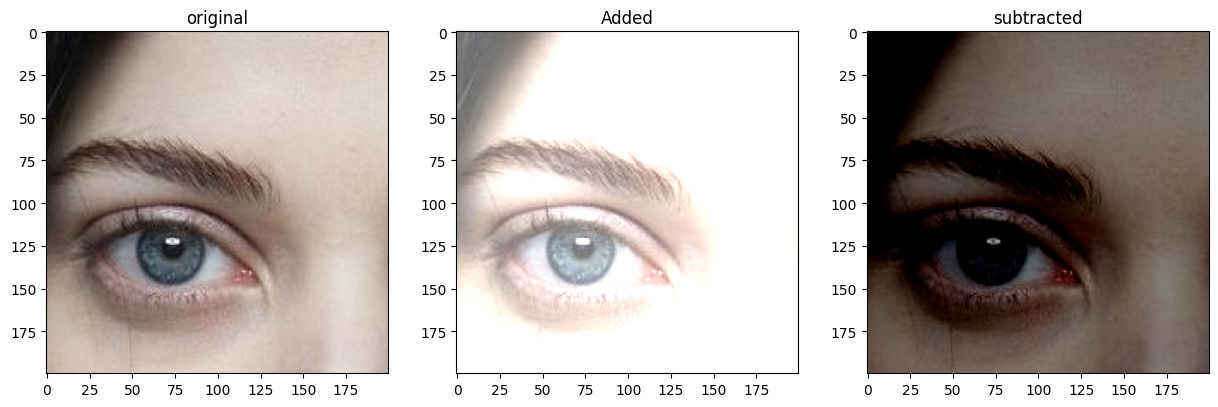

In [10]:
plt.figure(figsize=[15,5])
plt.subplot(131);plt.imshow(image[...,::-1]);plt.title("original")
plt.subplot(132);plt.imshow(added[...,::-1]);plt.title("Added")
plt.subplot(133);plt.imshow(sabtracted[...,::-1]);plt.title("subtracted")

cv2.imshow("oprjinal",image)
cv2.imshow('added',added)
cv2.imshow("subtracted",sabtracted)

cv2.waitKey()
cv2.destroyAllWindows()